# Lab 3: Data Processing for Machine Learning

## Brief Introduction of Dataset

The dataset we use for this lab session comes from the famous Titanic passenger dataset. It is
based on the real-world maritime disaster of the Titanic disaster 1912, involving the ship RMS
Titanic, which sank in 1912 after hitting an iceberg. Each row represents a passenger aboard the
Titanic, and the dataset records whether that passenger survived or not.

### Target Variable

***Survived (0 = Did not survive, 1 = Survived)***

### Key Features (Columns)

1. **Passenger Information**
    - PassengerId → Unique ID for each passenger
    - Name → Passenger name
    - Sex → Gender
    - Age → Age in years

2. **Socio-Economic Information**
    - Pclass → Passenger class (1st, 2nd, 3rd) - *Proxy for socio-economic status*
    - Fare → Ticket price paid

3. **Family Information**
    - SibSp → Number of siblings/spouses aboard
    - Parch → Number of parents/children aboard

4. **Travel Information**
    - Ticket → Ticket number
    - Cabin → Cabin number (many missing values)
    - Embarked → Port of embarkation
        - C = Cherbourg
        - Q = Queenstown
        - S = Southampton

### URL for the Dataset (CSV format)

https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv


## Part A: Loading Dataset and displaying basic information

In [1]:
# Task 1: Import required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Task 2: Load the dataset provided in csv format.
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

In [3]:
# Task 3: Display basic information
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Part B: Handling Missing Values

In [6]:
# Task 4: Check missing values.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

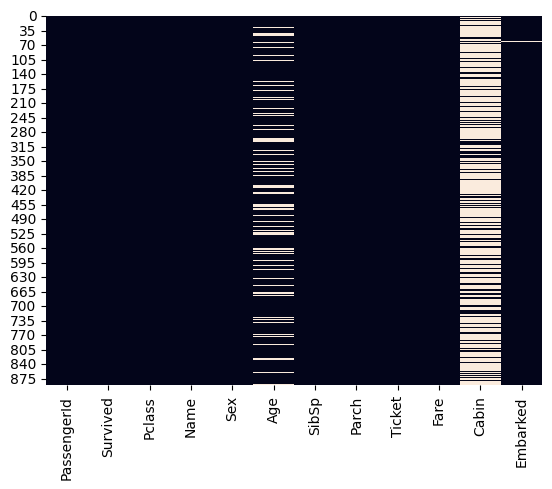

In [7]:
# Task 5: Visualize missing values in a heatmap.
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [8]:
# Task 6: Fill missing Age values with median.
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\kusha\AppData\Local\Temp\ipykernel_43776\1065781493.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [9]:
# Task 7: Fill missing Embarked values with mode.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\kusha\AppData\Local\Temp\ipykernel_43776\4189341165.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [10]:
# Task 8: Drop Cabin column.
df.drop('Cabin', axis=1, inplace=True)

## Part C: Encoding Categorical Variables

In [11]:
# Task 9: Identify categorical attributes.
df.select_dtypes(include='object').columns

C:\Users\kusha\AppData\Local\Temp\ipykernel_43776\2634742963.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [12]:
# Task 10: Apply Label Encoding.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [13]:
# Task 11: Apply One-Hot Encoding.
df = pd.get_dummies(df,columns=['Embarked'],drop_first=True)

## Part D: Feature Scaling

In [14]:
# Task 12: Select numerical columns.
num_cols = ['Age', 'Fare']

In [15]:
# Task 13: Apply Standardization.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [16]:
# Task 14: Observe transformed values.
df[['Age', 'Fare']].head()

,Age,Fare
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


## Part E: Outlier Detection

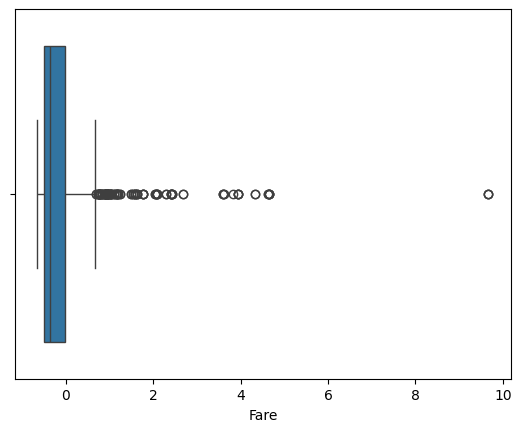

In [17]:
# Task 15: Draw boxplot.
sns.boxplot(x=df['Fare'])
plt.show()

In [18]:
# Task 16: Calculate Inter Quartile Range.
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [19]:
# Task 17: Find outliers.
outliers = df[(df['Fare'] < lower)|(df['Fare'] > upper)]
print(len(outliers))

116


## Part F: Feature Selection and Final Dataset

In [20]:
# Task 18: Remove unnecessary columns.
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [21]:
# Task 19: Separate features and target.
X = df.drop('Survived', axis=1)
y = df['Survived']

In [22]:
# Task 20: Check final shape.
print(X.shape)
print(y.shape)

(891, 8)
(891,)


## Conclusion

In this lab experiment, we learned about the data preprocessing for Machine Learning.
We preprocessed the publicly availabe `titanic dataset` and are now confident in 
data preprocessing techniques for Machine Learning.

## Additional Exercise

In [23]:
df = pd.read_csv(URL)

In [24]:
# Exercise 1: Count the number of male and female passengers.
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [25]:
# Exercise 2: Calculate average age before and after filling missing values.
avg_age_before = df['Age'].mean()
df['Age'].fillna(df['Age'].mean(), inplace=True)
avg_age_after = df['Age'].mean()

print(f"Average Age before filling: {avg_age_before}")
print(f"Average Age after filling: {avg_age_after}")

Average Age before filling: 29.69911764705882
Average Age after filling: 29.69911764705882


C:\Users\kusha\AppData\Local\Temp\ipykernel_43776\1062407763.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


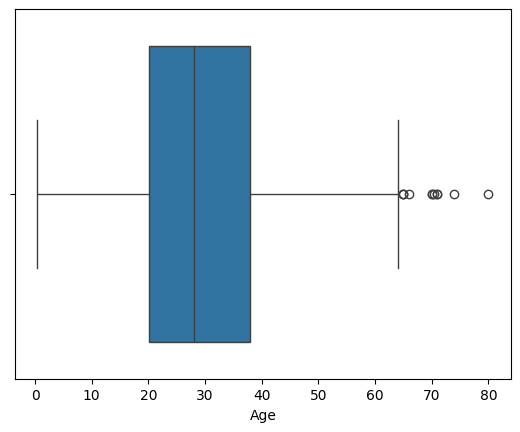

In [26]:
# Exercise 3: Detect outliers in the Age column.
sns.boxplot(x=df['Age'])
plt.show()

In [27]:
# Exercise 4: Apply Min-Max Scaling instead of Standardization.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = ['Age', 'Fare']
df[num_cols] = scaler.fit_transform(df[num_cols])

df[['Age', 'Fare']].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [28]:
# Exercise 5: Compare the results of Label Encoding and One-Hot Encoding.
# Exercise 5: Compare Label Encoding vs One-Hot Encoding for 'Sex'
df_le = df.copy()
df_le['Sex_LE'] = le.fit_transform(df_le['Sex'])

sex_ohe = pd.get_dummies(df['Sex'], prefix='Sex')

comparison = pd.concat([
    df[['Sex']].reset_index(drop=True),
    df_le['Sex_LE'].reset_index(drop=True),
    sex_ohe.reset_index(drop=True)
], axis=1)

print("Sample comparison:")
print(comparison.head(10))

print("\nShapes:")
print("Label Encoded (single column):", df_le[['Sex_LE']].shape)
print("One-Hot Encoded (columns):", sex_ohe.shape)

Sample comparison:
      Sex  Sex_LE  Sex_female  Sex_male
0    male       1       False      True
1  female       0        True     False
2  female       0        True     False
3  female       0        True     False
4    male       1       False      True
5    male       1       False      True
6    male       1       False      True
7    male       1       False      True
8  female       0        True     False
9  female       0        True     False

Shapes:
Label Encoded (single column): (891, 1)
One-Hot Encoded (columns): (891, 2)
